In [48]:
import pandas as pd
df = pd.read_csv('stroke_thrombectomy_dataset_2.csv')
df.head(3)

,patient_id,age,gender,bmi,nihss_score,gcs_score,systolic_bp,blood_glucose,oxygen_saturation,inr,...,smoking_history,onset_to_door_min,door_to_ct_min,ct_to_puncture_min,puncture_to_recanalization_min,onset_to_recanalization_min,tpa_given,interventionist_experience_years,mrs_90day,functional_independence
0,ST0001,72,Female,26.0,31,14,205,121,91,1.41,...,Current,99,5,32,61,197,0,23.0,2,1
1,ST0002,65,Female,19.5,14,13,134,142,92,1.51,...,Former,16,9,16,20,61,0,12.0,2,1
2,ST0003,74,Male,33.8,14,4,192,202,93,1.03,...,Never,212,12,65,43,332,0,16.0,2,1


In [49]:
df.columns

Index(['patient_id', 'age', 'gender', 'bmi', 'nihss_score', 'gcs_score',
       'systolic_bp', 'blood_glucose', 'oxygen_saturation', 'inr',
       'hemoglobin', 'creatinine', 'clot_location', 'clot_length_mm',
       'aspects_score', 'collateral_score', 'penumbra_volume_ml',
       'core_infarct_volume_ml', 'mismatch_ratio', 'hypertension', 'diabetes',
       'atrial_fibrillation', 'prior_stroke', 'smoking_history',
       'onset_to_door_min', 'door_to_ct_min', 'ct_to_puncture_min',
       'puncture_to_recanalization_min', 'onset_to_recanalization_min',
       'tpa_given', 'interventionist_experience_years', 'mrs_90day',
       'functional_independence'],
      dtype='object')

In [95]:
# Features Engineering
# Timings
df['arrvial_imaging_efficiency'] = df['door_to_ct_min'] / df['onset_to_door_min']
df['puncture_workflow_proportion'] = df['ct_to_puncture_min'] / df['onset_to_recanalization_min']
df['delay_interaction'] = df['onset_to_door_min'] * df['onset_to_recanalization_min']
df['late_arrival'] = df['onset_to_door_min'] > 270
df['very_late_recanalization'] = df['onset_to_recanalization_min'] > 360
df['recanalization_workflow_proportion'] = df['puncture_to_recanalization_min'] / df['onset_to_recanalization_min']

# Brain Tolerance
df['brain_reserve'] = df['aspects_score'] * df['collateral_score']
df['age_adjusted_penumbra'] = df['penumbra_volume_ml'] / (df['age']+1)
df['age_weighted_core'] = df['core_infarct_volume_ml'] * df['age']
df['aspects_penumbra_interaction'] = df['aspects_score'] * df['penumbra_volume_ml']

# Oxygen/ Metabolic Tolerance
df['cerebral_oxygen_reserve'] = df['oxygen_saturation'] * df['hemoglobin'] * df['collateral_score']
df['metabolic_infarct_burden'] = df['blood_glucose'] * df['core_infarct_volume_ml']
df['hemorrhagic_risk'] = df['systolic_bp'] * df['inr']
df['oxygen_per_deficit'] = df['oxygen_saturation'] / (df['nihss_score'] + 1)

# Imaging/Clot
df['penumbra_salvageable_ratio'] = df['penumbra_volume_ml'] / (df['penumbra_volume_ml'] + df['core_infarct_volume_ml'] + 1e-6)
df['salvageable_tissue'] = df['penumbra_volume_ml'] - df['core_infarct_volume_ml']
df['large_core'] = df['core_infarct_volume_ml'] > 70
df['clot_burden'] = df['clot_length_mm'] * df['core_infarct_volume_ml']
df['poor_aspects'] = df['aspects_score'] < 6
df['weighted_mismatch'] = df['mismatch_ratio'] * df['penumbra_volume_ml']

# Hemodynamic/Lab
df['oxygen_delivery'] = df['hemoglobin'] * df['oxygen_saturation']
df['metabolic_pressure_ratio'] = df['blood_glucose'] / df['systolic_bp']
df['hyperglycemia'] = df['blood_glucose'] > 180
df['hypertensive'] = df['systolic_bp'] > 180
df['coagulation_renal'] = df['inr'] * df['creatinine']
df['hemo_renal_ratio'] = df['hemoglobin'] / df['creatinine']

# Comorbidity
df['comorbidity_count'] = df['hypertension'] + df['diabetes'] + df['atrial_fibrillation'] + df['prior_stroke']
df['age_severity'] = df['age'] * df['nihss_score']
df['age_burden'] = df['age'] * df['comorbidity_count']
df['elderly'] = df['age'] > 80

# Surgical Risk
df['coagulation_severity'] = df['inr'] * df['nihss_score']
df['renal_delay_burden'] = df['creatinine'] * df['onset_to_recanalization_min']
df['cardiovascular_load'] = df['bmi'] * df['systolic_bp']
df['experience_adjusted_difficulty'] = df['interventionist_experience_years'] / (df['nihss_score'] + 1)
df['thrombolysis_timing'] = df['tpa_given'] * df['onset_to_recanalization_min']

# Brain Deterioration Rate
df['infarct_growth_rate'] = df['core_infarct_volume_ml'] / (df['onset_to_recanalization_min'] + 1)
df['deficit_per_viable_brain'] = df['nihss_score'] / (df['aspects_score'] + 1)
df['salvage_decay_rate'] = (df['penumbra_volume_ml'] - df['core_infarct_volume_ml']) / (df['onset_to_recanalization_min'] + 1)
df['core_to_penumbra_ratio'] = df['core_infarct_volume_ml'] / (df['penumbra_volume_ml'] + 1)

# Experience/Severity
df['case_difficulty'] = df['nihss_score'] / (df['interventionist_experience_years'] + 1)
df['severity_delay'] = df['nihss_score'] * df['onset_to_recanalization_min']
df['consciousness_deficit_ratio'] = df['gcs_score'] / (df['nihss_score'] + 1)
df['bmi_severity'] = df['bmi'] * df['nihss_score']
df['collateral_penumbra'] = df['collateral_score'] * df['penumbra_volume_ml']

In [96]:
df.isnull().sum()[::4]

patient_id                       0
nihss_score                      0
oxygen_saturation                0
clot_location                    0
penumbra_volume_ml             458
diabetes                         0
onset_to_door_min                0
onset_to_recanalization_min      0
functional_independence          0
delay_interaction                0
brain_reserve                  310
cerebral_oxygen_reserve        310
penumbra_salvageable_ratio     458
poor_aspects                     0
hyperglycemia                    0
comorbidity_count                0
coagulation_severity             0
thrombolysis_timing              0
core_to_penumbra_ratio         458
bmi_severity                     0
dtype: int64

In [51]:
from sklearn.preprocessing import LabelEncoder
df['gender'] = LabelEncoder().fit_transform(df.gender)

In [65]:
features = df.columns
features = features.drop('patient_id').drop('mrs_90day')
features = features.drop('functional_independence')

In [66]:
X = df[features]
Y = df.functional_independence

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, train_size=0.7, test_size=0.3, random_state=0)

In [68]:
categorical_cols = [i for i in X_train.columns if X_train[i].dtype == 'object']
numerical_cols = [i for i in X_train.columns if X_train[i].dtype in ['float64', 'int64']]
cols = categorical_cols + numerical_cols

In [69]:
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
def model_pipeline(numerical_cols, categorical_cols):
    numerical = KNNImputer(n_neighbors=5, weights='uniform')
    categorical = Pipeline(steps=[
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessing = ColumnTransformer(transformers=[
        ('num', numerical, numerical_cols),
        ('oh', categorical, categorical_cols)
    ])
    return preprocessing

In [70]:
from xgboost import XGBClassifier
model = Pipeline(steps=[
    ('preprocess', model_pipeline(numerical_cols, categorical_cols)),
    ('model', XGBClassifier(n_estimators=400, learning_rate=0.05))
])
model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('oh', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [71]:
#Before scores
pred1 = model.predict(X_valid)
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
print(roc_auc_score(Y_valid, pred1)*100)
print(accuracy_score(Y_valid, pred1)*100)

80.96513739438417
81.22222222222221


In [72]:
from sklearn.feature_selection import mutual_info_classif
def mutal_info(X, Y):
    imp = SimpleImputer(strategy='most_frequent')
    X = X.copy()
    for i in X.select_dtypes('object'):
        X[i], _ = X[i].factorize()
    X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    discrete_features = X.dtypes == int
    info = mutual_info_classif(X, Y, discrete_features=discrete_features)
    info = pd.Series(info, name='mutual_info', index=X.columns)
    return info.sort_values(ascending=False)

In [73]:
mi_scores = mutal_info(X_train[cols], Y_train)
weak_mi_scores = mi_scores[mi_scores == 0].index.to_list()
numerical_cols = [i for i in numerical_cols if i not in weak_mi_scores]
categorical_cols = [i for i in categorical_cols if i not in weak_mi_scores]
my_cols1 = numerical_cols + categorical_cols

In [74]:
model2 = Pipeline(steps=[
    ('preprocessing', model_pipeline(numerical_cols, categorical_cols)),
    ('model', XGBClassifier(n_estimators=400, learning_rate=0.05))
])
X_train2 = X_train[my_cols1]
valid_X1 = X_valid[my_cols1]
model2.fit(X_train2, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('oh', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
pred = model2.predict(valid_X1)
print(roc_auc_score(Y_valid, pred)*100)
print(accuracy_score(Y_valid, pred)*100)

77.8900844926688
78.11111111111111


In [76]:
# After fitting, check XGBoost's own importance
importance = pd.Series(
    model2.named_steps['model'].feature_importances_,
    index=model2.named_steps['preprocessing'].get_feature_names_out()
).sort_values(ascending=False)

<Axes: >

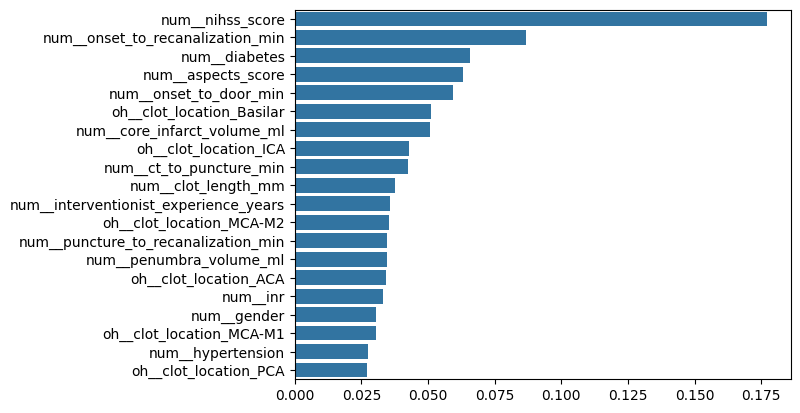

In [77]:
importance[::3]
sns.barplot(data=importance, orient='h')